# Assignment No: 03
#### Rollno. - 33157 DIV-A (TE-CS)

**Datasets:**
- `loan_data.csv` and its Source: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load loan_data.csv
df = pd.read_csv('loan_data.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (367, 12)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0             1.0         Urban  
1             1.0         Urban  
2             1.0         Urban  
3    

In [ ]:
# Handle Missing Values
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
print("Missing values handled.")
print(df.isnull().sum())

Missing values handled.
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [ ]:
# Step 1: Summary Statistics grouped by Education
print("Summary of ApplicantIncome grouped by Education:")
grouped = df.groupby('Education')['ApplicantIncome'].agg(
    Mean='mean', Median='median', Std='std', Min='min', Max='max'
).round(2)
print(grouped)

Summary of ApplicantIncome grouped by Education:
                 Mean  Median      Std  Min    Max
Education                                         
Graduate      5169.94  4000.0  5442.52    0  72529
Not Graduate  3578.11  3276.0  1928.73    0  13083


Summary of LoanAmount grouped by Property_Area:
                 Mean  Median    Std   Min    Max
Property_Area                                    
Rural          138.06   130.0  56.15  28.0  390.0
Semiurban      133.89   123.5  61.27  35.0  550.0
Urban          136.06   125.0  64.62  28.0  460.0


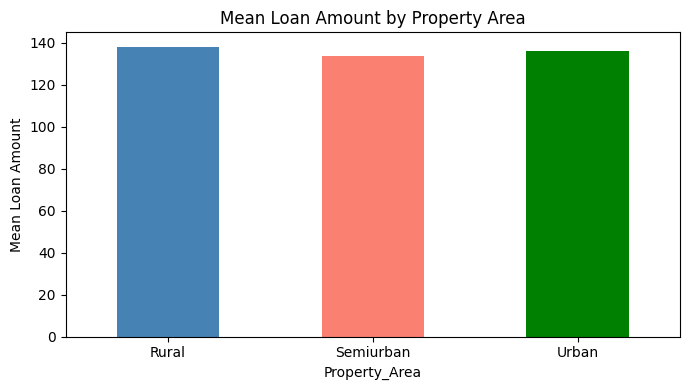

In [ ]:
# Summary of LoanAmount grouped by Property_Area
print("Summary of LoanAmount grouped by Property_Area:")
grouped2 = df.groupby('Property_Area')['LoanAmount'].agg(
    Mean='mean', Median='median', Std='std', Min='min', Max='max'
).round(2)
print(grouped2)

grouped2['Mean'].plot(kind='bar', color=['steelblue','salmon','green'], figsize=(7,4))
plt.title('Mean Loan Amount by Property Area')
plt.ylabel('Mean Loan Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Step 2: Load Iris Dataset
iris = sns.load_dataset('iris')
print("Iris Shape:", iris.shape)
print(iris.head())

Iris Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
# Statistical Details per Species
for sp in iris['species'].unique():
    print(f"\n=== {sp.upper()} ===")
    subset = iris[iris['species'] == sp].drop('species', axis=1)
    print(subset.describe().round(3))


=== SETOSA ===
       sepal_length  sepal_width  petal_length  petal_width
count        50.000       50.000        50.000       50.000
mean          5.006        3.428         1.462        0.246
std           0.352        0.379         0.174        0.105
min           4.300        2.300         1.000        0.100
25%           4.800        3.200         1.400        0.200
50%           5.000        3.400         1.500        0.200
75%           5.200        3.675         1.575        0.300
max           5.800        4.400         1.900        0.600

=== VERSICOLOR ===
       sepal_length  sepal_width  petal_length  petal_width
count        50.000       50.000         50.00       50.000
mean          5.936        2.770          4.26        1.326
std           0.516        0.314          0.47        0.198
min           4.900        2.000          3.00        1.000
25%           5.600        2.525          4.00        1.200
50%           5.900        2.800          4.35        1.300
75% 

In [ ]:
# Central Tendency and Dispersion using NumPy
print("=== Central Tendency and Dispersion (Full Iris) ===")
for col in iris.columns[:-1]:
    data = iris[col]
    print(f"\n{col}:")
    print(f"  Mean     : {np.mean(data):.4f}")
    print(f"  Median   : {np.median(data):.4f}")
    print(f"  Mode     : {stats.mode(data, keepdims=True).mode[0]:.4f}")
    print(f"  Variance : {np.var(data):.4f}")
    print(f"  Std Dev  : {np.std(data):.4f}")
    print(f"  Q1       : {np.percentile(data,25):.4f}")
    print(f"  Q3       : {np.percentile(data,75):.4f}")
    print(f"  IQR      : {stats.iqr(data):.4f}")

=== Central Tendency and Dispersion (Full Iris) ===

sepal_length:
  Mean     : 5.8433
  Median   : 5.8000
  Mode     : 5.0000
  Variance : 0.6811
  Std Dev  : 0.8253
  Q1       : 5.1000
  Q3       : 6.4000
  IQR      : 1.3000

sepal_width:
  Mean     : 3.0573
  Median   : 3.0000
  Mode     : 3.0000
  Variance : 0.1887
  Std Dev  : 0.4344
  Q1       : 2.8000
  Q3       : 3.3000
  IQR      : 0.5000

petal_length:
  Mean     : 3.7580
  Median   : 4.3500
  Mode     : 1.4000
  Variance : 3.0955
  Std Dev  : 1.7594
  Q1       : 1.6000
  Q3       : 5.1000
  IQR      : 3.5000

petal_width:
  Mean     : 1.1993
  Median   : 1.3000
  Mode     : 0.2000
  Variance : 0.5771
  Std Dev  : 0.7597
  Q1       : 0.3000
  Q3       : 1.8000
  IQR      : 1.5000


In [ ]:
# MinMaxScaler Normalization on Iris
scaler = MinMaxScaler()
iris_num = iris.drop('species', axis=1)
iris_scaled = pd.DataFrame(scaler.fit_transform(iris_num), columns=iris_num.columns)
print("Normalized Iris (first 5 rows):")
print(iris_scaled.head())

Normalized Iris (first 5 rows):
   sepal_length  sepal_width  petal_length  petal_width
0      0.222222     0.625000      0.067797     0.041667
1      0.166667     0.416667      0.067797     0.041667
2      0.111111     0.500000      0.050847     0.041667
3      0.083333     0.458333      0.084746     0.041667
4      0.194444     0.666667      0.067797     0.041667
